### Assignment 6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Expanded_data_with_more_features.csv')
data.head()

Mounted at /content/drive


,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [ ]:
data.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


the target :MathScore ReadingScore WritingScore
    potential features : the rest of the columns except column "Unnamed: 0"

## Data Preprocessing

In [ ]:
data.drop('Unnamed: 0', axis= 1, inplace=True)

In [ ]:
data.isnull().sum()

,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572
TransportMeans,3134


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


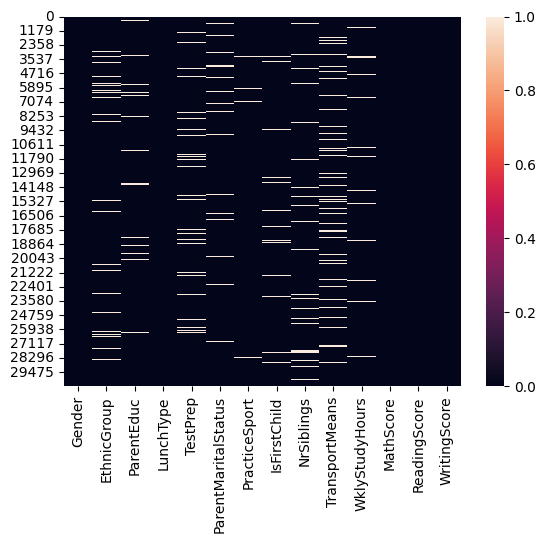

In [ ]:
sns.heatmap(data.isna())
plt.show()

In [ ]:
#DROP NOT IMPORTANT CLUMNS:
data = data.drop(['ParentMaritalStatus', 'IsFirstChild', 'TransportMeans'], axis=1)

In [ ]:
data["NrSiblings"]=data["NrSiblings"].fillna(data["NrSiblings"].mean())

In [ ]:
categorical_imputation=["EthnicGroup","ParentEduc","TestPrep","PracticeSport","WklyStudyHours"]
for col in categorical_imputation:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipython-input-1709283254.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
data.isna().sum()

,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
PracticeSport,0
NrSiblings,0
WklyStudyHours,0
MathScore,0
ReadingScore,0


## Handling Duplicates

In [ ]:
data.duplicated().sum()

np.int64(5)

In [ ]:
data=data.drop_duplicates()

In [ ]:
data.duplicated().sum()

np.int64(0)

## Outlier Detection

In [ ]:
outliers = data.select_dtypes('number').columns

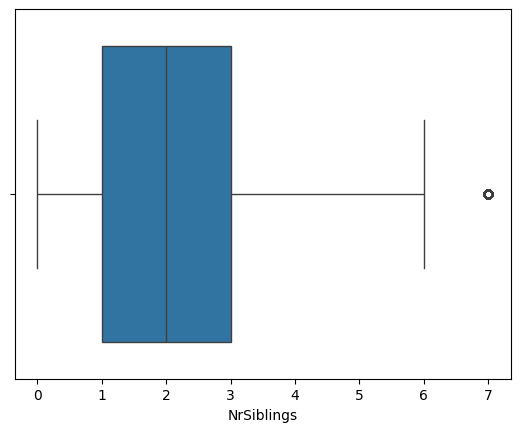

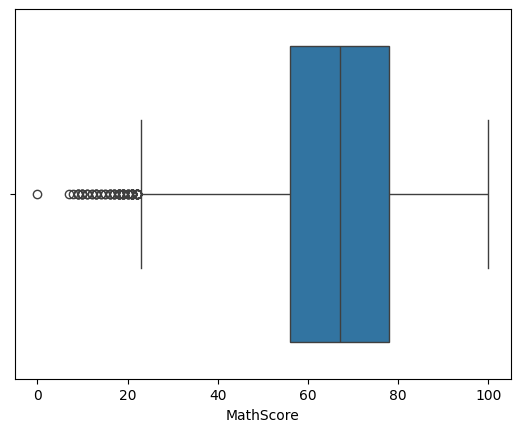

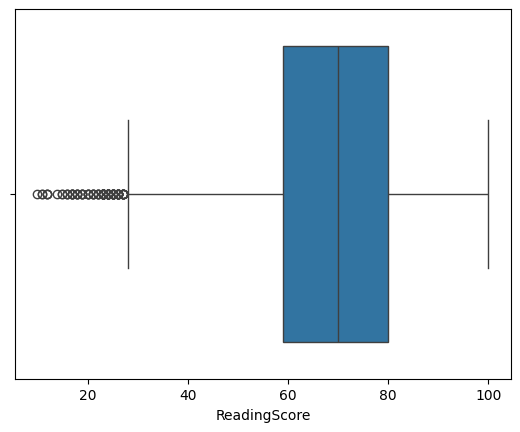

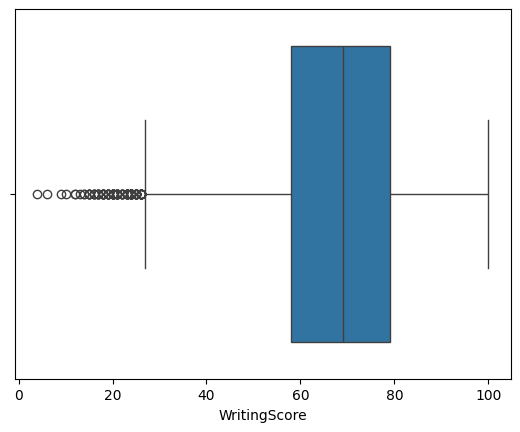

In [ ]:
for col in outliers:
    sns.boxplot(data=data, x=col)
    plt.show()

In [ ]:
for col in outliers:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    mymin = Q1 - 1.5 * IQR
    mymax = Q3 + 1.5 * IQR
    data = data[(data[col] > mymin) & (data[col] < mymax)]

In [ ]:
data.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore
count,29867.000000,29867.000000,29867.000000,29867.000000
mean,2.061038,66.803629,69.621991,68.672649
std,1.293434,15.051577,14.448861,15.124365
min,0.000000,24.000000,28.000000,27.000000
25%,1.000000,56.000000,60.000000,58.000000
50%,2.000000,67.000000,70.000000,69.000000
75%,3.000000,78.000000,80.000000,79.000000
max,5.000000,100.000000,100.000000,100.000000


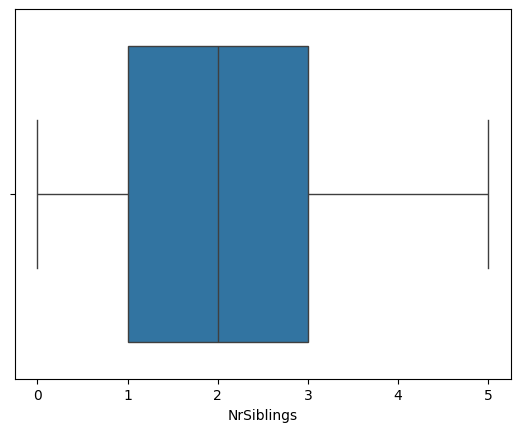

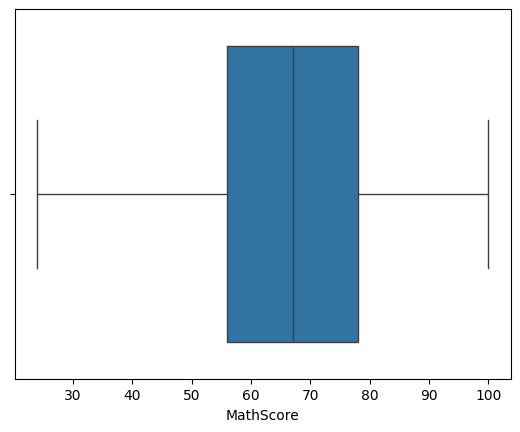

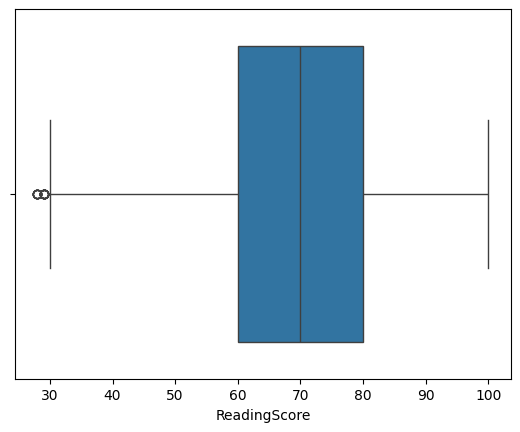

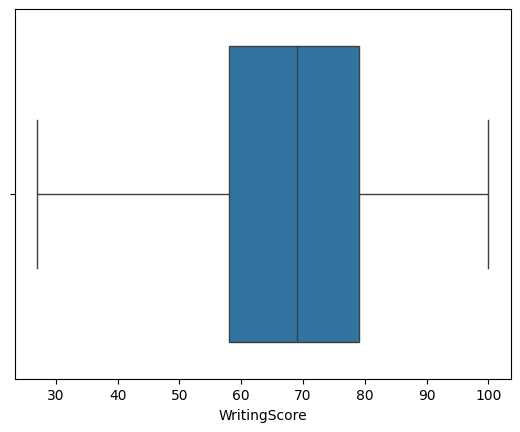

In [ ]:
for col in outliers:
    sns.boxplot(data=data, x=col)
    plt.show()

## Encoding categorical features

In [ ]:
data.reset_index(drop=True,inplace=True)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder , LabelEncoder

In [ ]:
data.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,PracticeSport,NrSiblings,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,group C,bachelor's degree,standard,none,regularly,3.0,< 5,71,71,74
1,female,group C,some college,standard,none,sometimes,0.0,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,sometimes,4.0,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,never,1.0,5 - 10,45,56,42
4,male,group C,some college,standard,none,sometimes,0.0,5 - 10,76,78,75


Ordinal encoding columns:ParentEduc, PracticeSport ,WklyStudyHours....
OneHot encoding columns:Gender, EthnicGroup, LunchType, TestPrep

In [ ]:
One_Hot_Col=["Gender", "EthnicGroup", "LunchType", "TestPrep"]

In [ ]:
data[One_Hot_Col] = data[One_Hot_Col].astype(str)
OHEncoder= OneHotEncoder(sparse_output=False, drop= 'if_binary')
OneHot_features = OHEncoder.fit_transform(data[One_Hot_Col])
OHencoded_data = pd.DataFrame(OneHot_features, columns= OHEncoder.get_feature_names_out(One_Hot_Col))


In [ ]:
for col in ["ParentEduc", "PracticeSport", "WklyStudyHours"]:
    print(f"\n{col} unique values:")
    print(data[col].unique())


ParentEduc unique values:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

PracticeSport unique values:
['regularly' 'sometimes' 'never']

WklyStudyHours unique values:
['< 5' '5 - 10' '> 10']


In [ ]:
Ordinal_Col=["ParentEduc","PracticeSport", "WklyStudyHours"]
ParentEduc_order= ['some high school', 'high school', "associate's degree", 'some college', "bachelor's degree", "master's degree"]
PracticeSport_order= ['never', 'sometimes', 'regularly']
WklyStudyHours_order= ['< 5', '5 - 10', '> 10']
Ordencoder = OrdinalEncoder(categories= [ParentEduc_order,PracticeSport_order, WklyStudyHours_order])
Ordinal_features = Ordencoder.fit_transform(data[Ordinal_Col])
Ordinal_data=pd.DataFrame(Ordinal_features, columns= Ordencoder.get_feature_names_out(Ordinal_Col))


In [ ]:
data.drop(One_Hot_Col,axis=1,inplace=True)
data.drop(Ordinal_Col,axis=1,inplace=True)
Encoded_data= pd.concat((data, OHencoded_data,Ordinal_data), axis=1)
Encoded_data.head()

,NrSiblings,MathScore,ReadingScore,WritingScore,Gender_male,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,LunchType_standard,TestPrep_none,ParentEduc,PracticeSport,WklyStudyHours
0,3.0,71,71,74,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,0.0
1,0.0,69,90,88,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,1.0,1.0
2,4.0,87,93,91,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,1.0,0.0
3,1.0,45,56,42,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0
4,0.0,76,78,75,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,1.0,1.0


In [ ]:
Encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29867 entries, 0 to 29866
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NrSiblings           29867 non-null  float64
 1   MathScore            29867 non-null  int64  
 2   ReadingScore         29867 non-null  int64  
 3   WritingScore         29867 non-null  int64  
 4   Gender_male          29867 non-null  float64
 5   EthnicGroup_group A  29867 non-null  float64
 6   EthnicGroup_group B  29867 non-null  float64
 7   EthnicGroup_group C  29867 non-null  float64
 8   EthnicGroup_group D  29867 non-null  float64
 9   EthnicGroup_group E  29867 non-null  float64
 10  LunchType_standard   29867 non-null  float64
 11  TestPrep_none        29867 non-null  float64
 12  ParentEduc           29867 non-null  float64
 13  PracticeSport        29867 non-null  float64
 14  WklyStudyHours       29867 non-null  float64
dtypes: float64(12), int64(3)
memory usag

In [ ]:
Encoded_data['ParentEduc'].unique()
#Encoded_data['PracticeSport'].unique()


array([4., 3., 5., 2., 1., 0.])

## EDA

### Target Distribution

In [ ]:
targets = ['MathScore', 'ReadingScore', 'WritingScore']

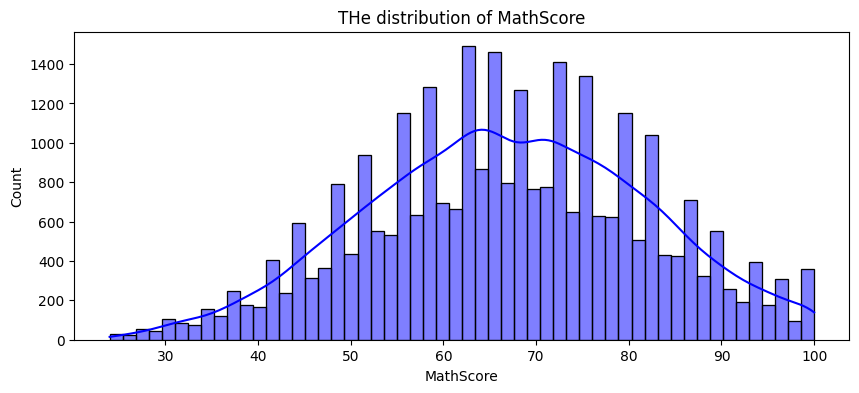

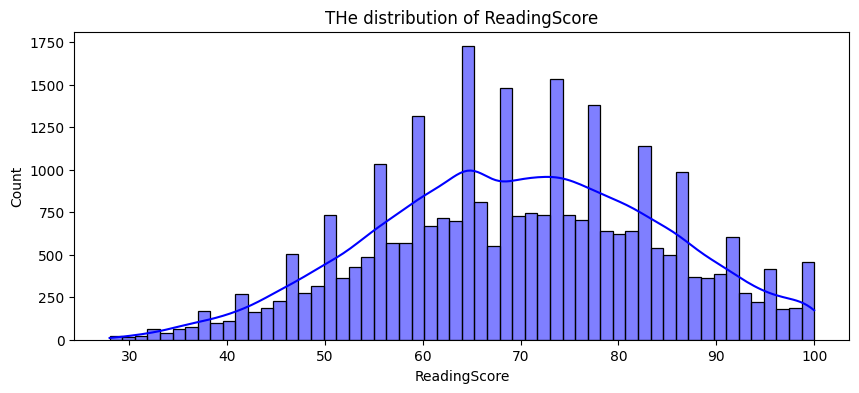

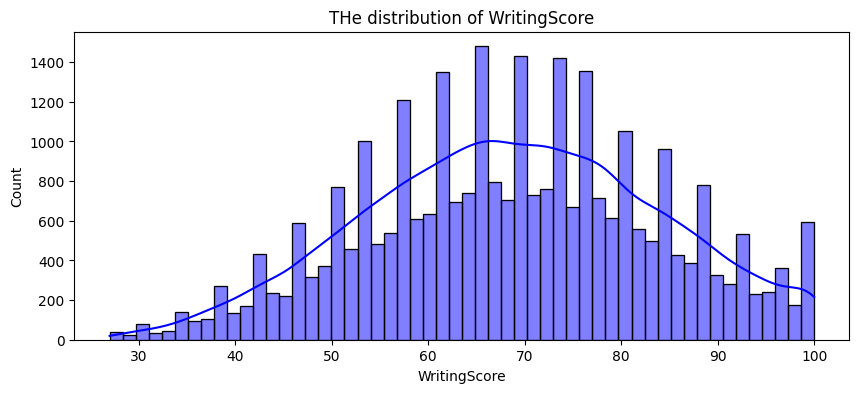

In [ ]:
for col in targets:
    plt.figure(figsize=(10,4))
    sns.histplot(Encoded_data[col], kde=True, color='blue')
    plt.title(f'THe distribution of {col}')
    plt.xlabel(col)
    #plt.ylabel('Count')
    plt.show()


### Correlation Matrix + Heatmap

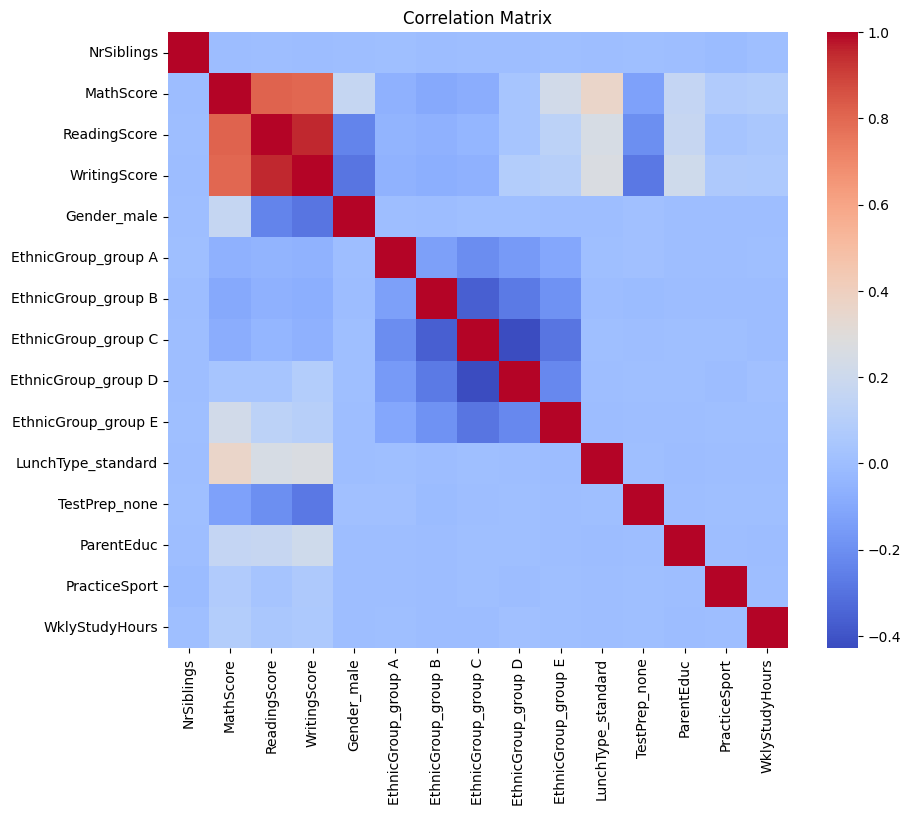

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
corr = Encoded_data.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()


## spliting Data

In [ ]:
#three models, same features different target
math_target=Encoded_data["MathScore"]
reading_target=Encoded_data["ReadingScore"]
writing_target=Encoded_data["WritingScore"]
all_targets=["WritingScore","MathScore","ReadingScore"]
features=Encoded_data.drop(all_targets, axis= 1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train_math, y_test_math = train_test_split(features, math_target, test_size=0.2, random_state=42)
x_train, x_test, y_train_reading, y_test_reading = train_test_split(features, reading_target, test_size=0.2, random_state=42)
x_train, x_test, y_train_writing, y_test_writing = train_test_split(features, writing_target, test_size=0.2, random_state=42)

## Feature Scaling

In [ ]:
Encoded_data.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore,Gender_male,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,LunchType_standard,TestPrep_none,ParentEduc,PracticeSport,WklyStudyHours
count,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000,29867.000000
mean,2.061038,66.803629,69.621991,68.672649,0.495731,0.072187,0.189540,0.359896,0.245991,0.132387,0.651890,0.673419,2.155322,1.222419,0.900860
std,1.293434,15.051577,14.448861,15.124365,0.499990,0.258801,0.391944,0.479978,0.430680,0.338917,0.476379,0.468970,1.481944,0.658777,0.654596
min,0.000000,24.000000,28.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,56.000000,60.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,2.000000,67.000000,70.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.000000
75%,3.000000,78.000000,80.000000,79.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,3.000000,2.000000,1.000000
max,5.000000,100.000000,100.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2.000000,2.000000


There is No need to scale features

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score

## Math Model

In [ ]:
math_model=LinearRegression()
math_model.fit(x_train, y_train_math)

LinearRegression()

In [ ]:
y_pred_math=math_model.predict(x_test)
MAE_math= mean_absolute_error(y_test_math,y_pred_math)
RMSE_math= root_mean_squared_error(y_test_math,y_pred_math)
R2_score_math= r2_score(y_test_math,y_pred_math)

In [ ]:
print(f"Math Target: MAE {MAE_math} , RMSE {RMSE_math}, R2 {R2_score_math}")

Math Target: MAE 10.440242613062953 , RMSE 12.81777564341005, R2 0.2673595696869848


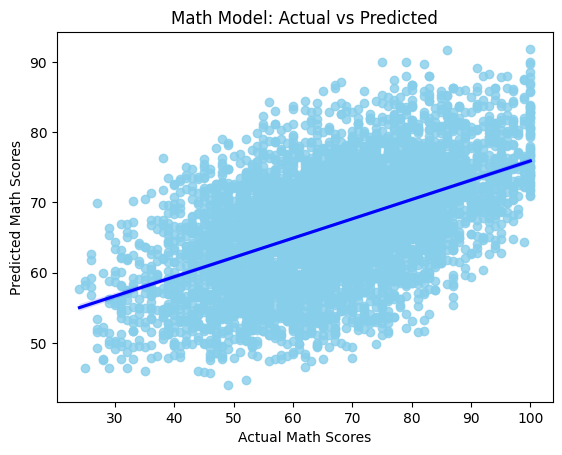

In [ ]:
sns.regplot(x=y_test_math, y=y_pred_math, color='skyblue', line_kws={'color':'blue'})
plt.title('Math Model: Actual vs Predicted')
plt.xlabel('Actual Math Scores')
plt.ylabel('Predicted Math Scores')
plt.show()

## Reading Model

In [ ]:
reading_model=LinearRegression()
reading_model.fit(x_train, y_train_math)

LinearRegression()

In [ ]:
y_pred_reading=reading_model.predict(x_test)
MAE_reading= mean_absolute_error(y_test_reading,y_pred_reading)
RMSE_reading= root_mean_squared_error(y_test_reading,y_pred_reading)
R2_score_reading= r2_score(y_test_reading,y_pred_reading)

In [ ]:
print(f"reading Target: MAE {MAE_reading} , RMSE {RMSE_reading}, R2 {R2_score_reading}")

reading Target: MAE 11.987274344859154 , RMSE 14.722063584954718, R2 -0.05026050405556748


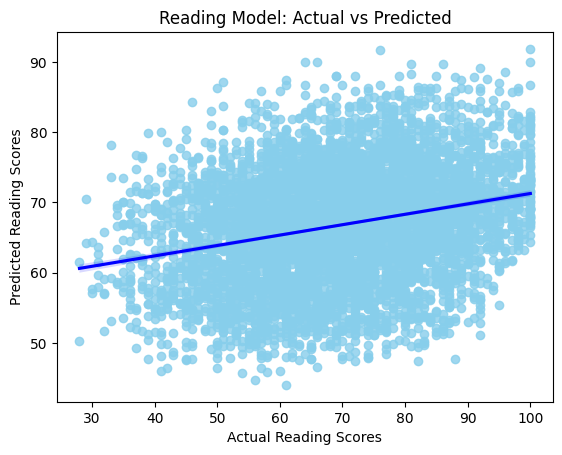

In [ ]:
sns.regplot(x=y_test_reading, y=y_pred_reading, color='skyblue', line_kws={'color':'blue'})
plt.title('Reading Model: Actual vs Predicted')
plt.xlabel('Actual Reading Scores')
plt.ylabel('Predicted Reading Scores')
plt.show()

## Writing Model

In [ ]:
writing_model=LinearRegression()
writing_model.fit(x_train, y_train_math)

LinearRegression()

In [ ]:
y_pred_writing=writing_model.predict(x_test)
MAE_writing= mean_absolute_error(y_test_writing,y_pred_writing)
RMSE_writing= root_mean_squared_error(y_test_writing,y_pred_writing)
R2_score_writing= r2_score(y_test_writing,y_pred_writing)

In [ ]:
print(f"writing Target: MAE {MAE_writing} , RMSE {RMSE_writing}, R2 {R2_score_writing}")

writing Target: MAE 12.16885435683497 , RMSE 14.910458672605124, R2 0.027773589245786767


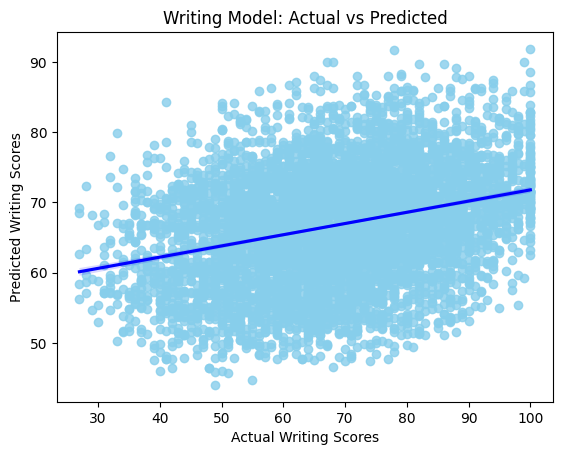

In [ ]:
sns.regplot(x=y_test_writing, y=y_pred_writing, color='skyblue', line_kws={'color':'blue'})
plt.title('Writing Model: Actual vs Predicted')
plt.xlabel('Actual Writing Scores')
plt.ylabel('Predicted Writing Scores')
plt.show()

# Conclusion

This project demonstrated the complete workflow of building a Linear Regression model, including data preprocessing, exploratory data analysis, feature scaling, model training, and evaluation.

The model achieved reasonable performance and captured the overall relationship between the input features and the target variable. While the predictions were not perfect, the evaluation metrics and visualizations showed that Linear Regression can effectively model the underlying trends in the dataset.

Future improvements could include feature selection, feature engineering, hyperparameter tuning, and experimenting with more advanced regression algorithms to further enhance predictive performance.